# YOLOv8 Object Detection - Transfer Learning & Evaluation Report (Colab Notebook)

## Step 1: Environment Setup

We install the ultralytics package and extract the uploaded dataset.zip to the working directory.

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.4 MB/s eta 0:00:00


In [2]:
!unzip -q /content/dataset.zip -d /content/dataset

## Step 2: YOLOv8 Head-only Fine-tuning (Backbone Frozen)

In [3]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n model with COCO weights.
# This model includes a backbone (feature extractor) and a detection head (predicts bounding boxes and classes).
model = YOLO('yolov8n.pt')

# Start training the model with only the detection head being updated.
# The first 10 layers (usually the backbone) are frozen, meaning their weights are not updated.
model.train(
    data='/content/dataset/data.yaml',  # Path to the dataset config in YOLO format
    epochs=20,                           # Number of training epochs
    imgsz=416,                           # Resize input images to 416x416
    batch=8,                             # Batch size per iteration
    workers=2,                           # Number of data loader workers
    freeze=10,                           # Freeze the first 10 layers (usually the backbone)
    name='colab_yolo_freeze_head',       # Name of this training run
    project='/content/runs/train',       # Where to save the training logs and weights
    pretrained=True,                     # Use pretrained weights from COCO
    mosaic=0.0,                          # Disable mosaic data augmentation
    hsv_h=0.0, hsv_s=0.0, hsv_v=0.0,     # Disable HSV augmentation
    flipud=0.0,                          # Disable vertical flipping
    erasing=0.0                          # Disable random erasing
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 336MB/s]


Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=colab_yolo_freeze_head, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 87.5MB/s]

Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      20/20      1.67G      1.085      1.087      1.225         65        416: 100%|██████████| 916/916 [01:16<00:00, 11.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:15<00:00,  8.47it/s]


                   all       2098      18916      0.496      0.413       0.44      0.301

20 epochs completed in 0.534 hours.
Optimizer stripped from /content/runs/train/colab_yolo_freeze_head/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/train/colab_yolo_freeze_head/weights/best.pt, 6.2MB

Validating /content/runs/train/colab_yolo_freeze_head/weights/best.pt...
Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:16<00:00,  7.83it/s]


                   all       2098      18916      0.495      0.413       0.44      0.301
         BIODEGRADABLE        676      13637      0.763      0.424      0.563      0.314
             CARDBOARD        438       1292      0.638       0.48      0.542      0.397
                 GLASS        805       2380      0.796        0.6      0.709      0.523
                 METAL        398       1360      0.553      0.524      0.526      0.351
                 PAPER         15         33     0.0132     0.0606     0.0663     0.0658
               PLASTIC         91        214      0.209      0.388      0.237      0.156
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/train/colab_yolo_freeze_head


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb943eea8d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

## Step 3: Training Result Visualization

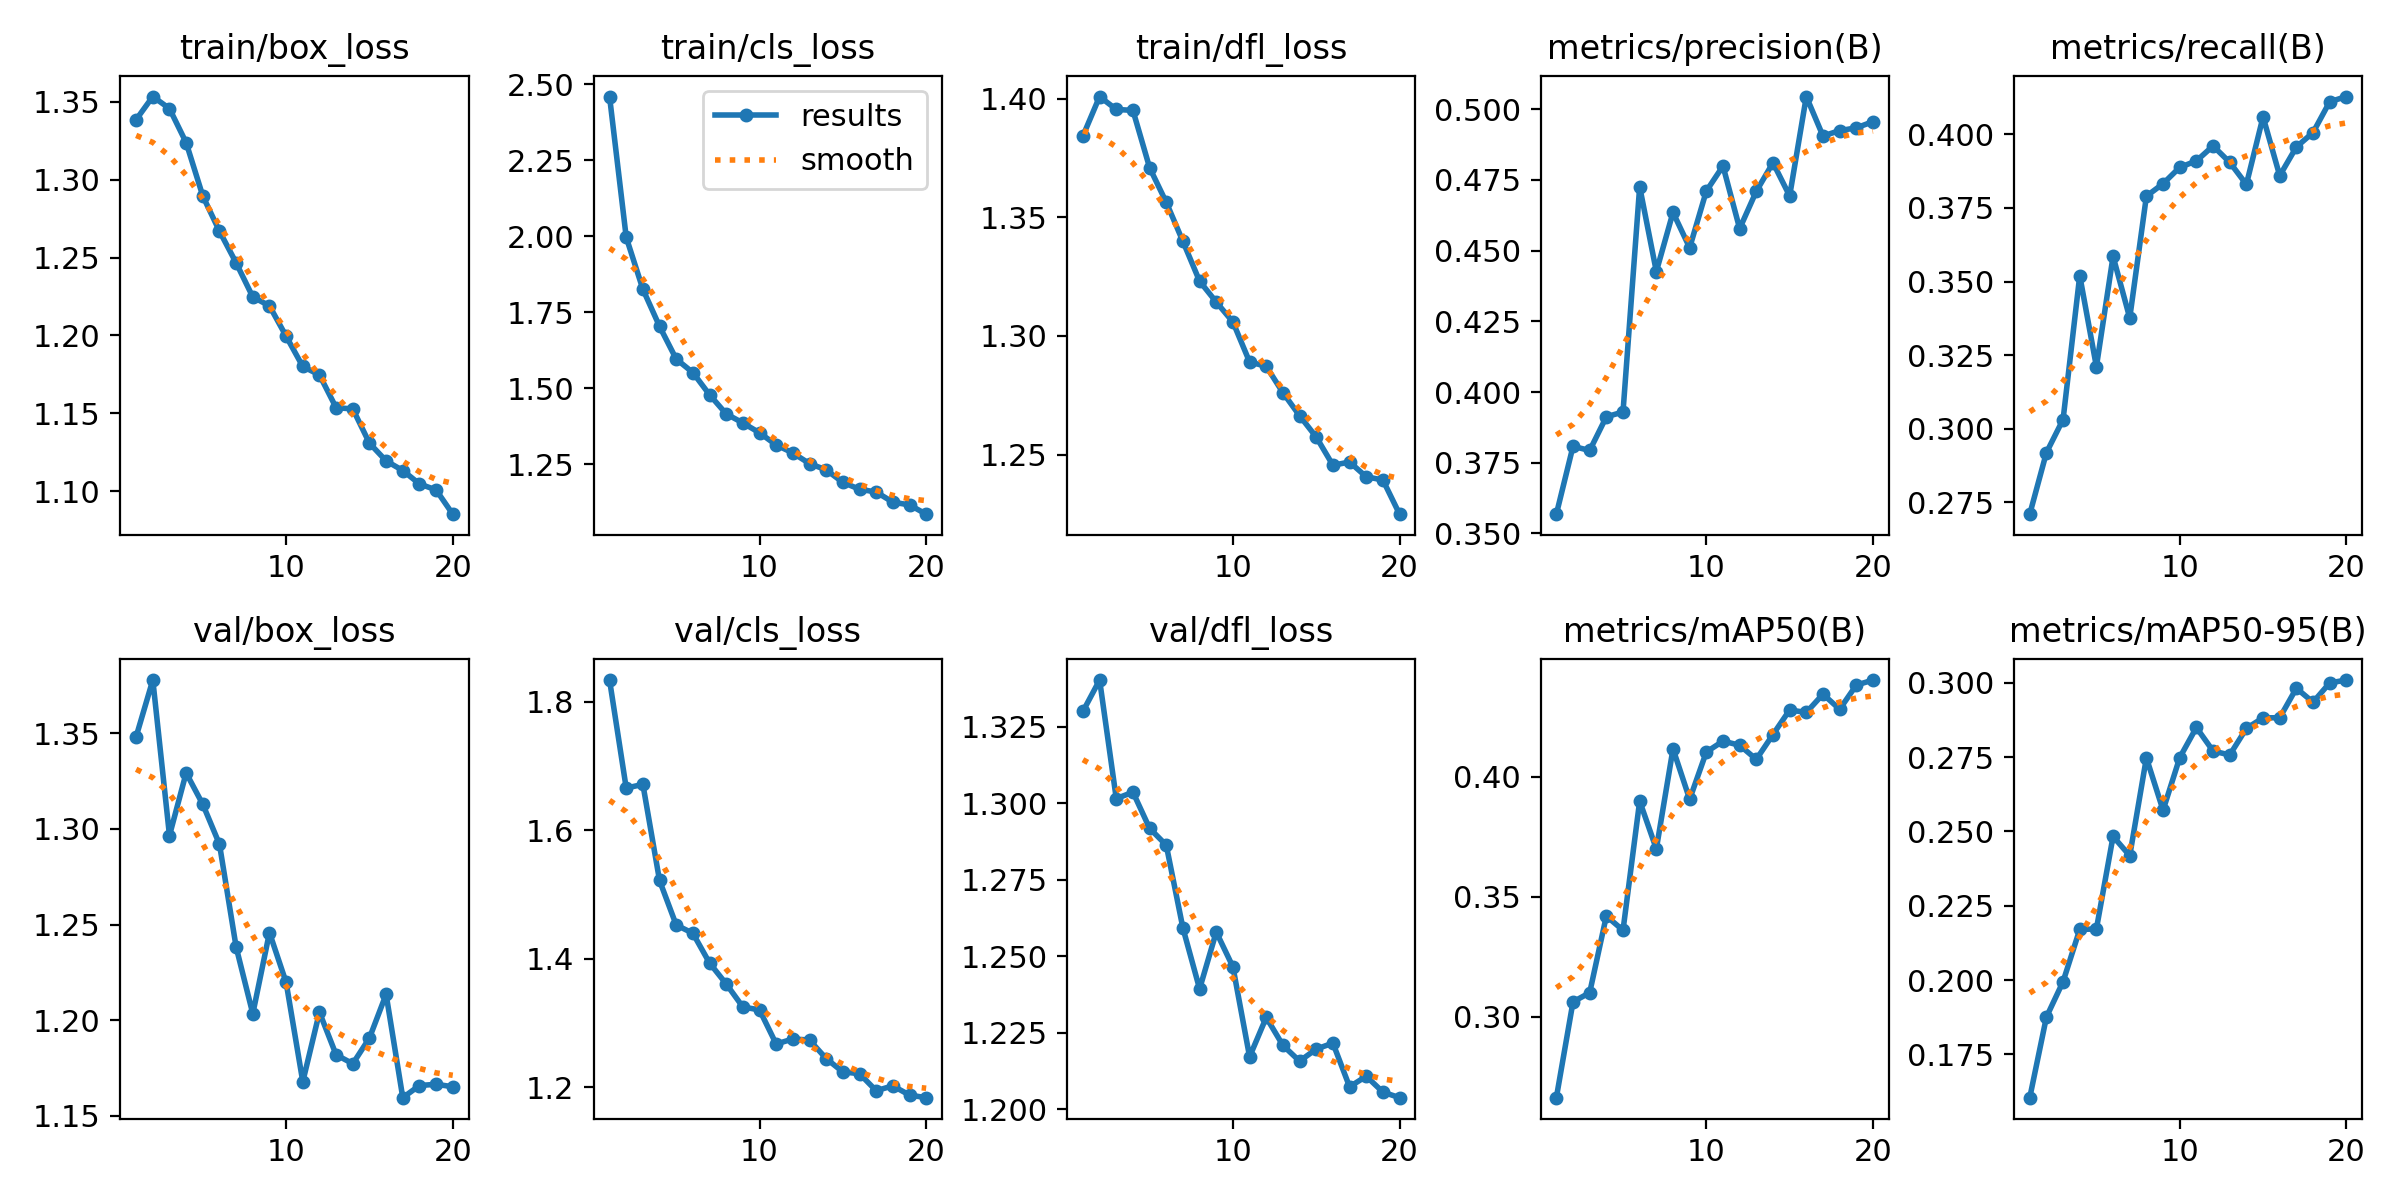

In [6]:
import pandas as pd
from IPython.display import Image

# Load training metrics
df = pd.read_csv('/content/runs/train/colab_yolo_freeze_head/results.csv')
df.tail()

# Plot training curves (loss, mAP)
Image(filename='/content/runs/train/colab_yolo_freeze_head/results.png')

This displays training progress including box loss, classification loss, mAP@50, and mAP@50-95.

## Step 4: Evaluate on Val Set and Test Set

In [17]:
model = YOLO('/content/runs/train/colab_yolo_freeze_head/weights/best.pt')
metrics_val = model.val(data='/content/dataset/data.yaml', split='val', project='runs/detect',name='val_result')

print("mAP50:", metrics_val.box.map50)         # AP@0.5
print("mAP50-95:", metrics_val.box.map)        # AP@[.5:.95]
print("Precision (mean):", metrics_val.box.mp) # Mean precision
print("Recall (mean):", metrics_val.box.mr)    # Mean recall
print("Per-class AP@50:", metrics_val.box.ap50)   # List of AP@50 per class
print("Per-class AP@50-95:", metrics_val.box.ap)  # List of AP@50-95 per class

Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 781.8±395.1 MB/s, size: 24.8 KB)


val: Scanning /content/dataset/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2098/2098 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:16<00:00,  7.82it/s]


                   all       2098      18916      0.495      0.413       0.44      0.301
         BIODEGRADABLE        676      13637      0.763      0.424      0.563      0.314
             CARDBOARD        438       1292      0.638       0.48      0.542      0.397
                 GLASS        805       2380      0.795      0.601      0.708      0.523
                 METAL        398       1360      0.553      0.523      0.527      0.351
                 PAPER         15         33     0.0129     0.0606     0.0663     0.0658
               PLASTIC         91        214       0.21      0.388      0.236      0.156
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val_result
mAP50: 0.4403824386564688
mAP50-95: 0.30120263327876357
Precision (mean): 0.49547151235825676
Recall (mean): 0.41269347799487127
Per-class AP@50: [    0.56285     0.54202     0.70818     0.52677    0.066308     0.23616]
Per-class AP@50-95: [    0.31415   

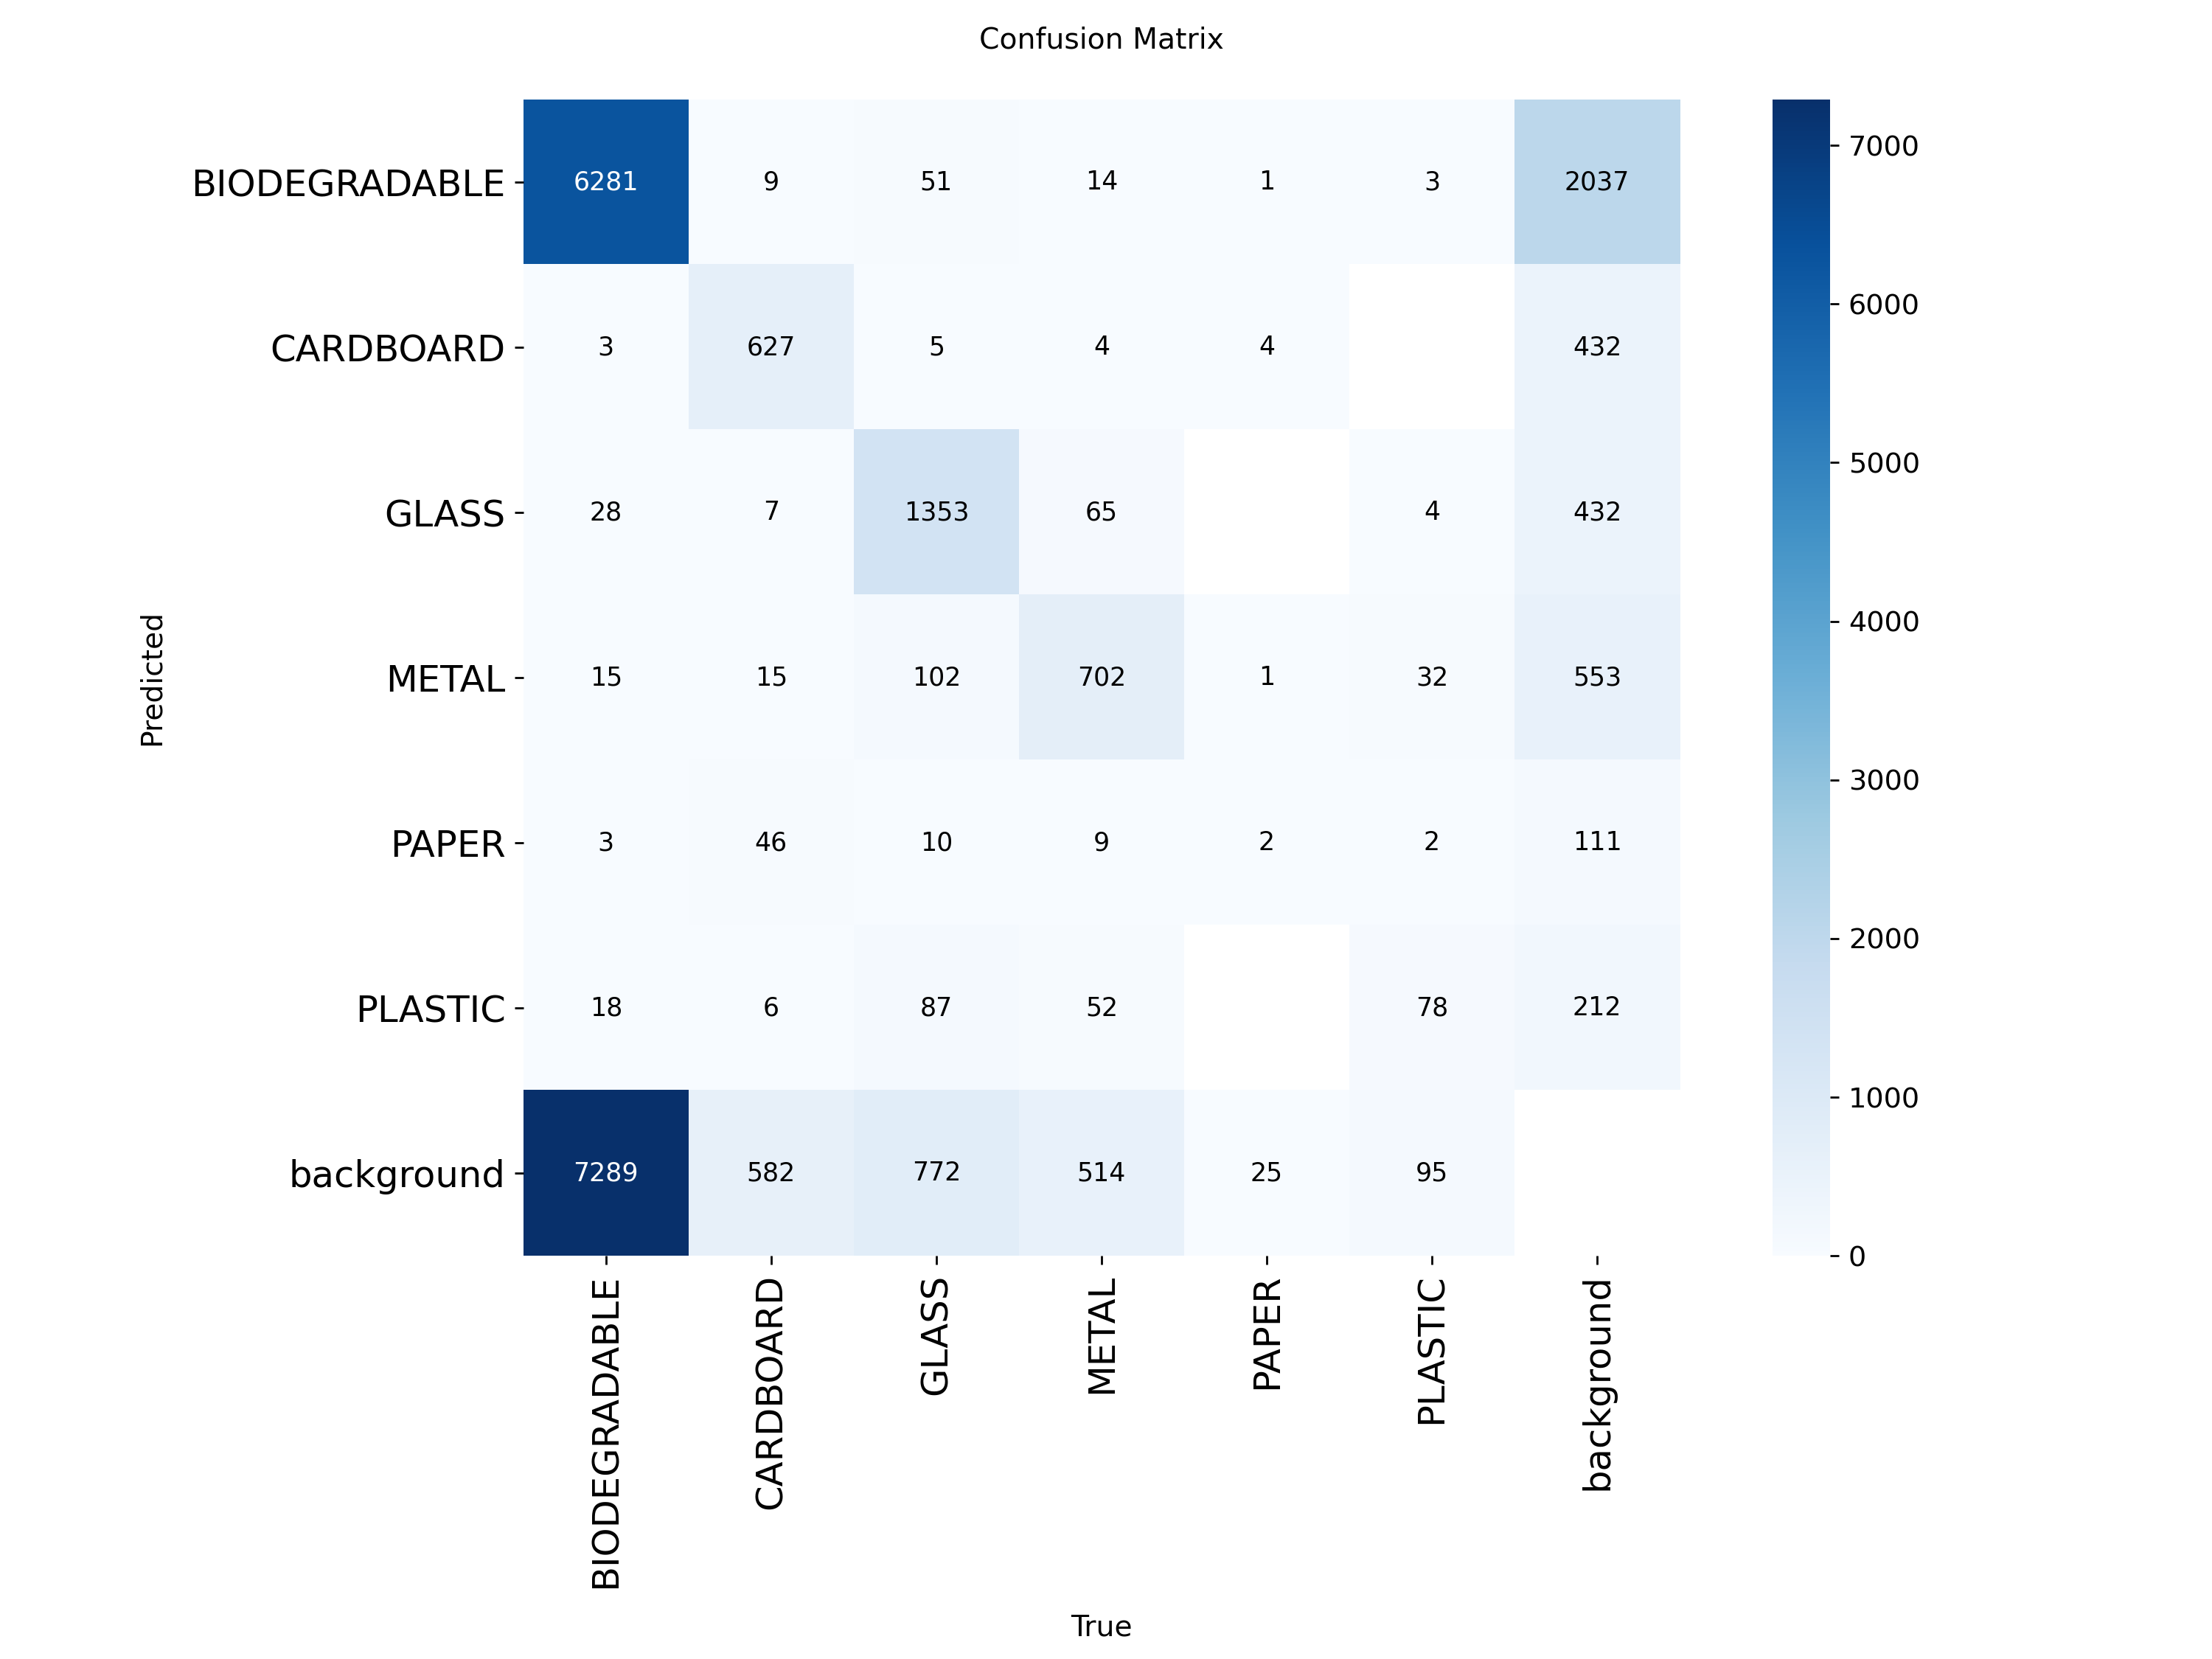

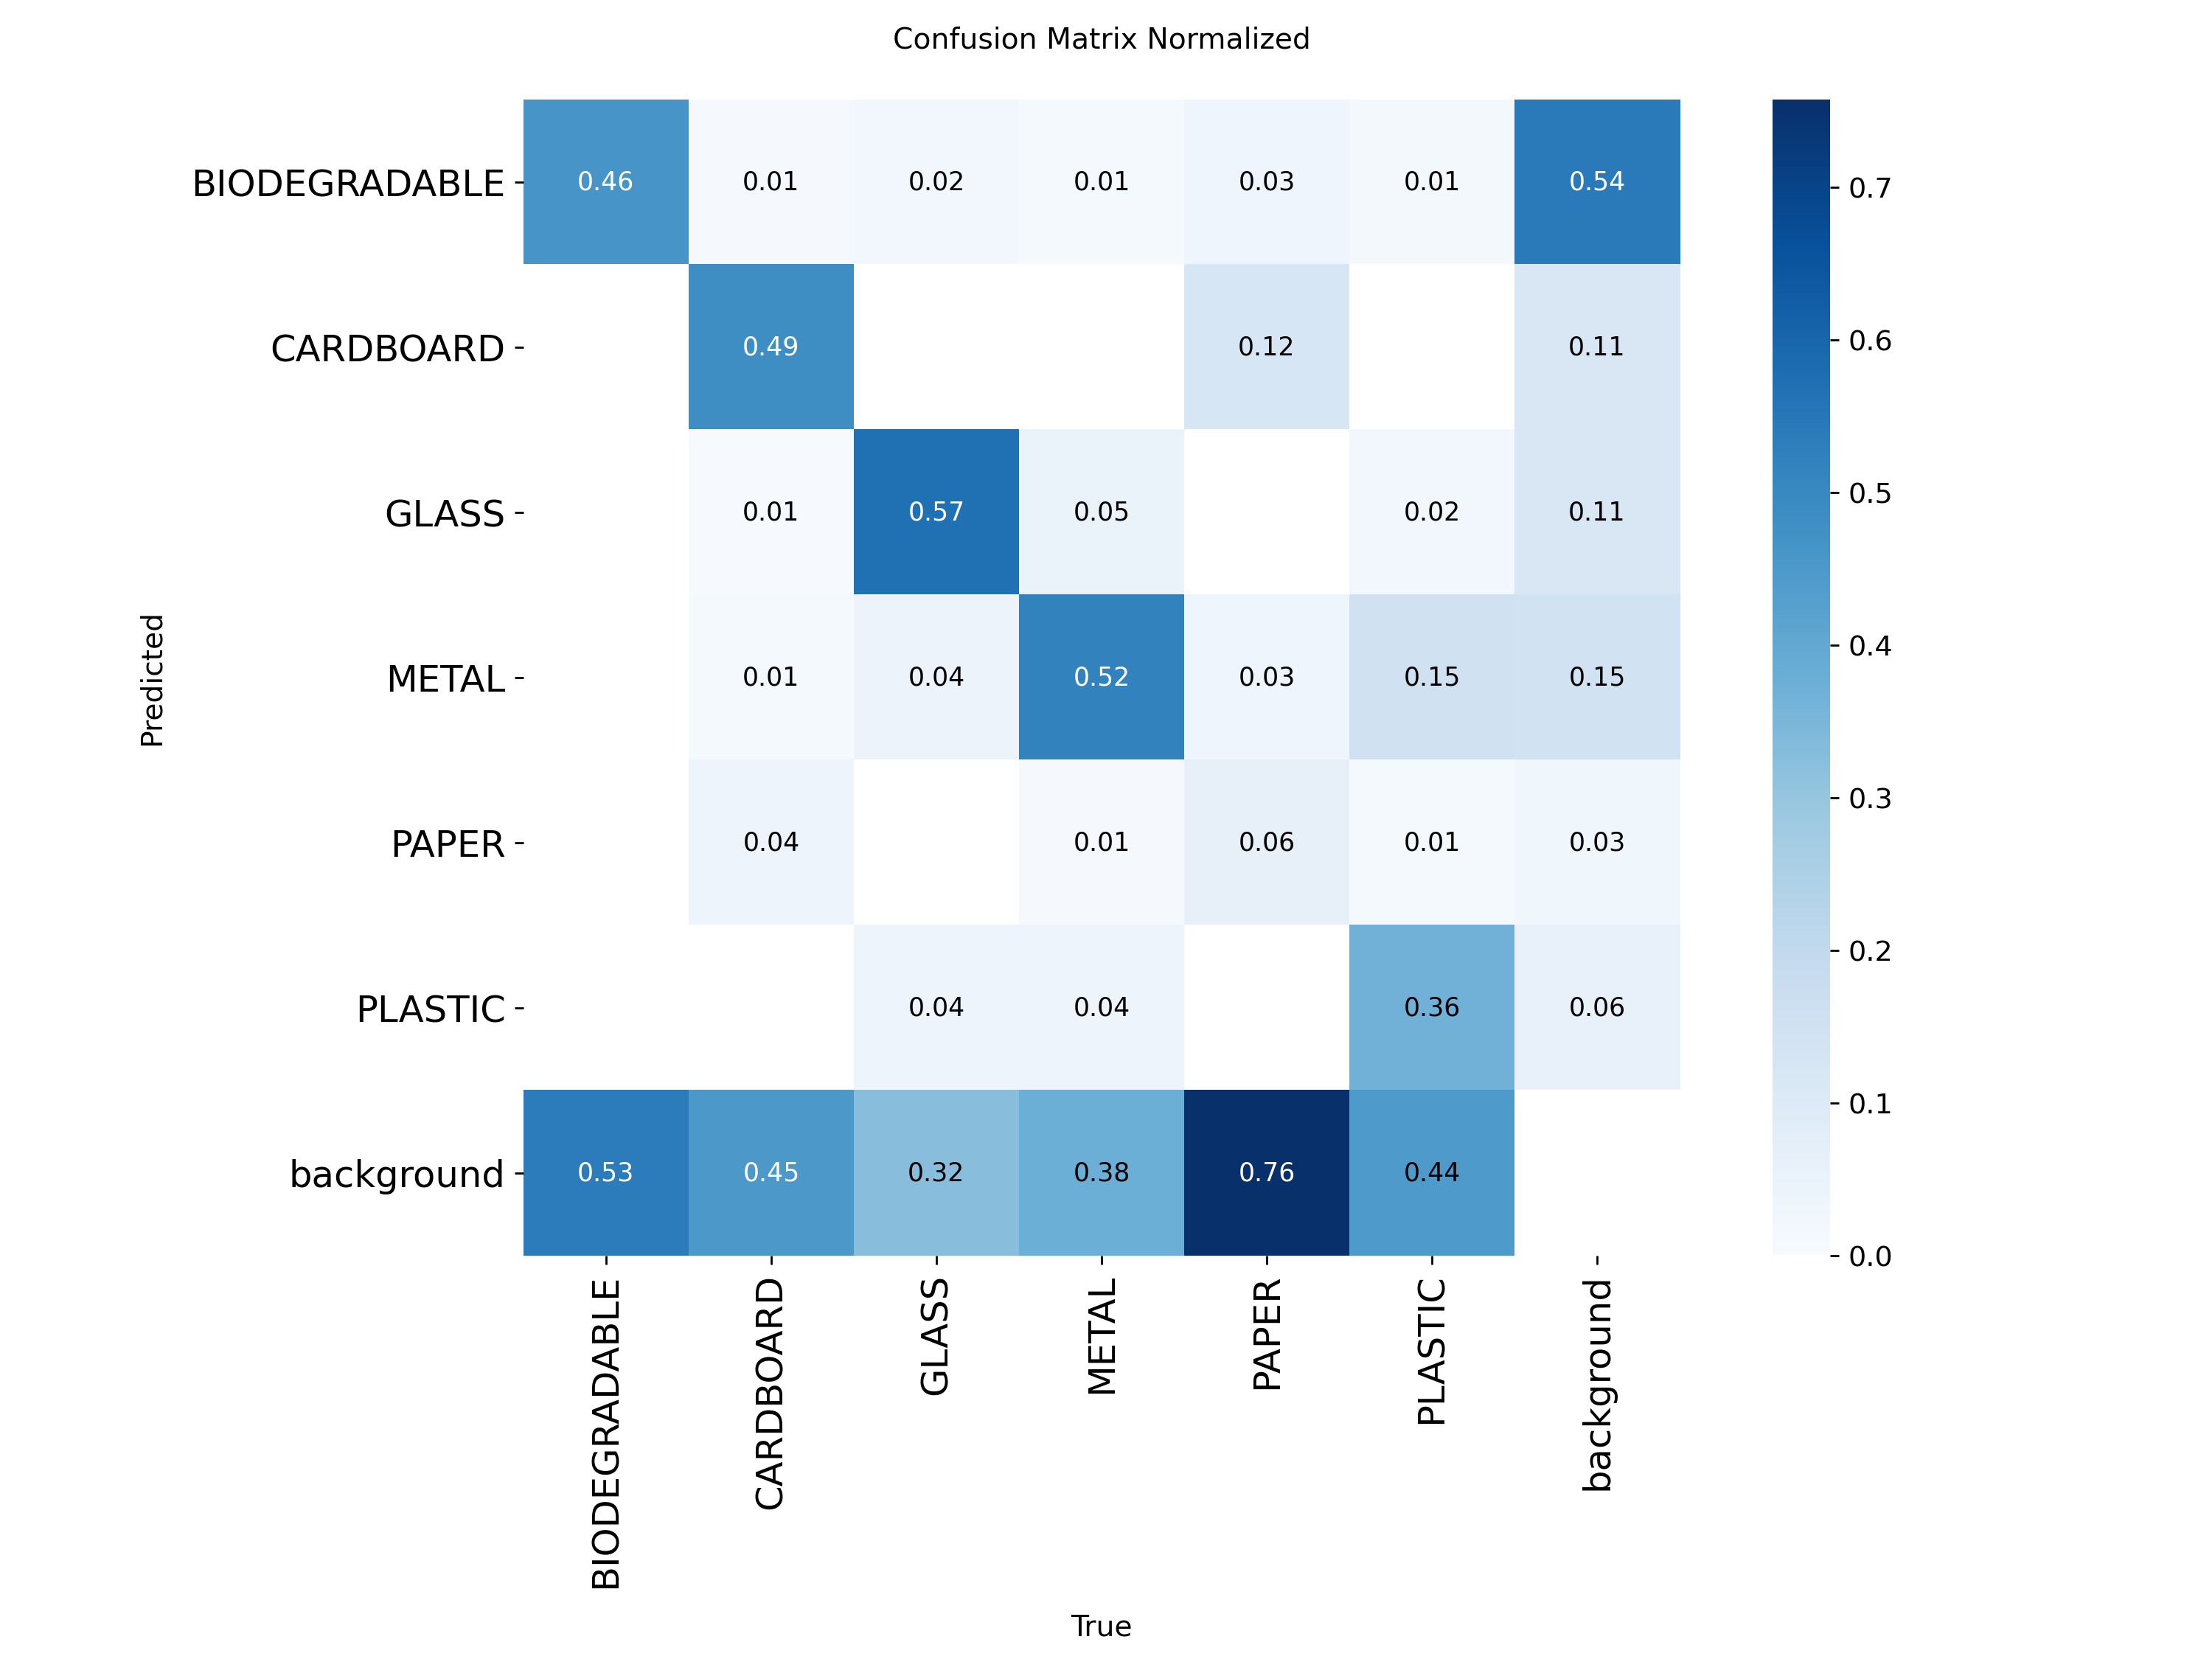

In [18]:
display(Image('/content/runs/detect/val_result/confusion_matrix.png'))
display(Image('/content/runs/detect/val_result/confusion_matrix_normalized.png'))

In [19]:
model = YOLO('/content/runs/train/colab_yolo_freeze_head/weights/best.pt')
metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    project='runs/detect',
    name='test_result'
)

print("mAP50:", metrics.box.map50)         # AP@0.5
print("mAP50-95:", metrics.box.map)        # AP@[.5:.95]
print("Precision (mean):", metrics.box.mp) # Mean precision
print("Recall (mean):", metrics.box.mr)    # Mean recall
print("Per-class AP@50:", metrics.box.ap50)   # List of AP@50 per class
print("Per-class AP@50-95:", metrics.box.ap)  # List of AP@50-95 per class


Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 624.7±154.9 MB/s, size: 21.3 KB)


val: Scanning /content/dataset/test/labels.cache... 1042 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1042/1042 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 66/66 [00:09<00:00,  7.23it/s]


                   all       1042       3563      0.419      0.376       0.36      0.266
         BIODEGRADABLE          8         49     0.0721      0.143     0.0547     0.0378
             CARDBOARD         11         20     0.0431        0.2     0.0314     0.0208
                 METAL        172        533      0.597      0.619      0.616       0.49
                 PAPER        515       1376      0.704      0.435      0.531      0.399
               PLASTIC        354       1585      0.677      0.481      0.569      0.382
Speed: 0.4ms preprocess, 1.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to runs/detect/test_result
mAP50: 0.36025078132018223
mAP50-95: 0.265886316888406
Precision (mean): 0.41872764444174565
Recall (mean): 0.37554038317548527
Per-class AP@50: [   0.054709    0.031352     0.61555     0.53091     0.56874]
Per-class AP@50-95: [   0.037819    0.020836     0.48972      0.3992     0.38185]


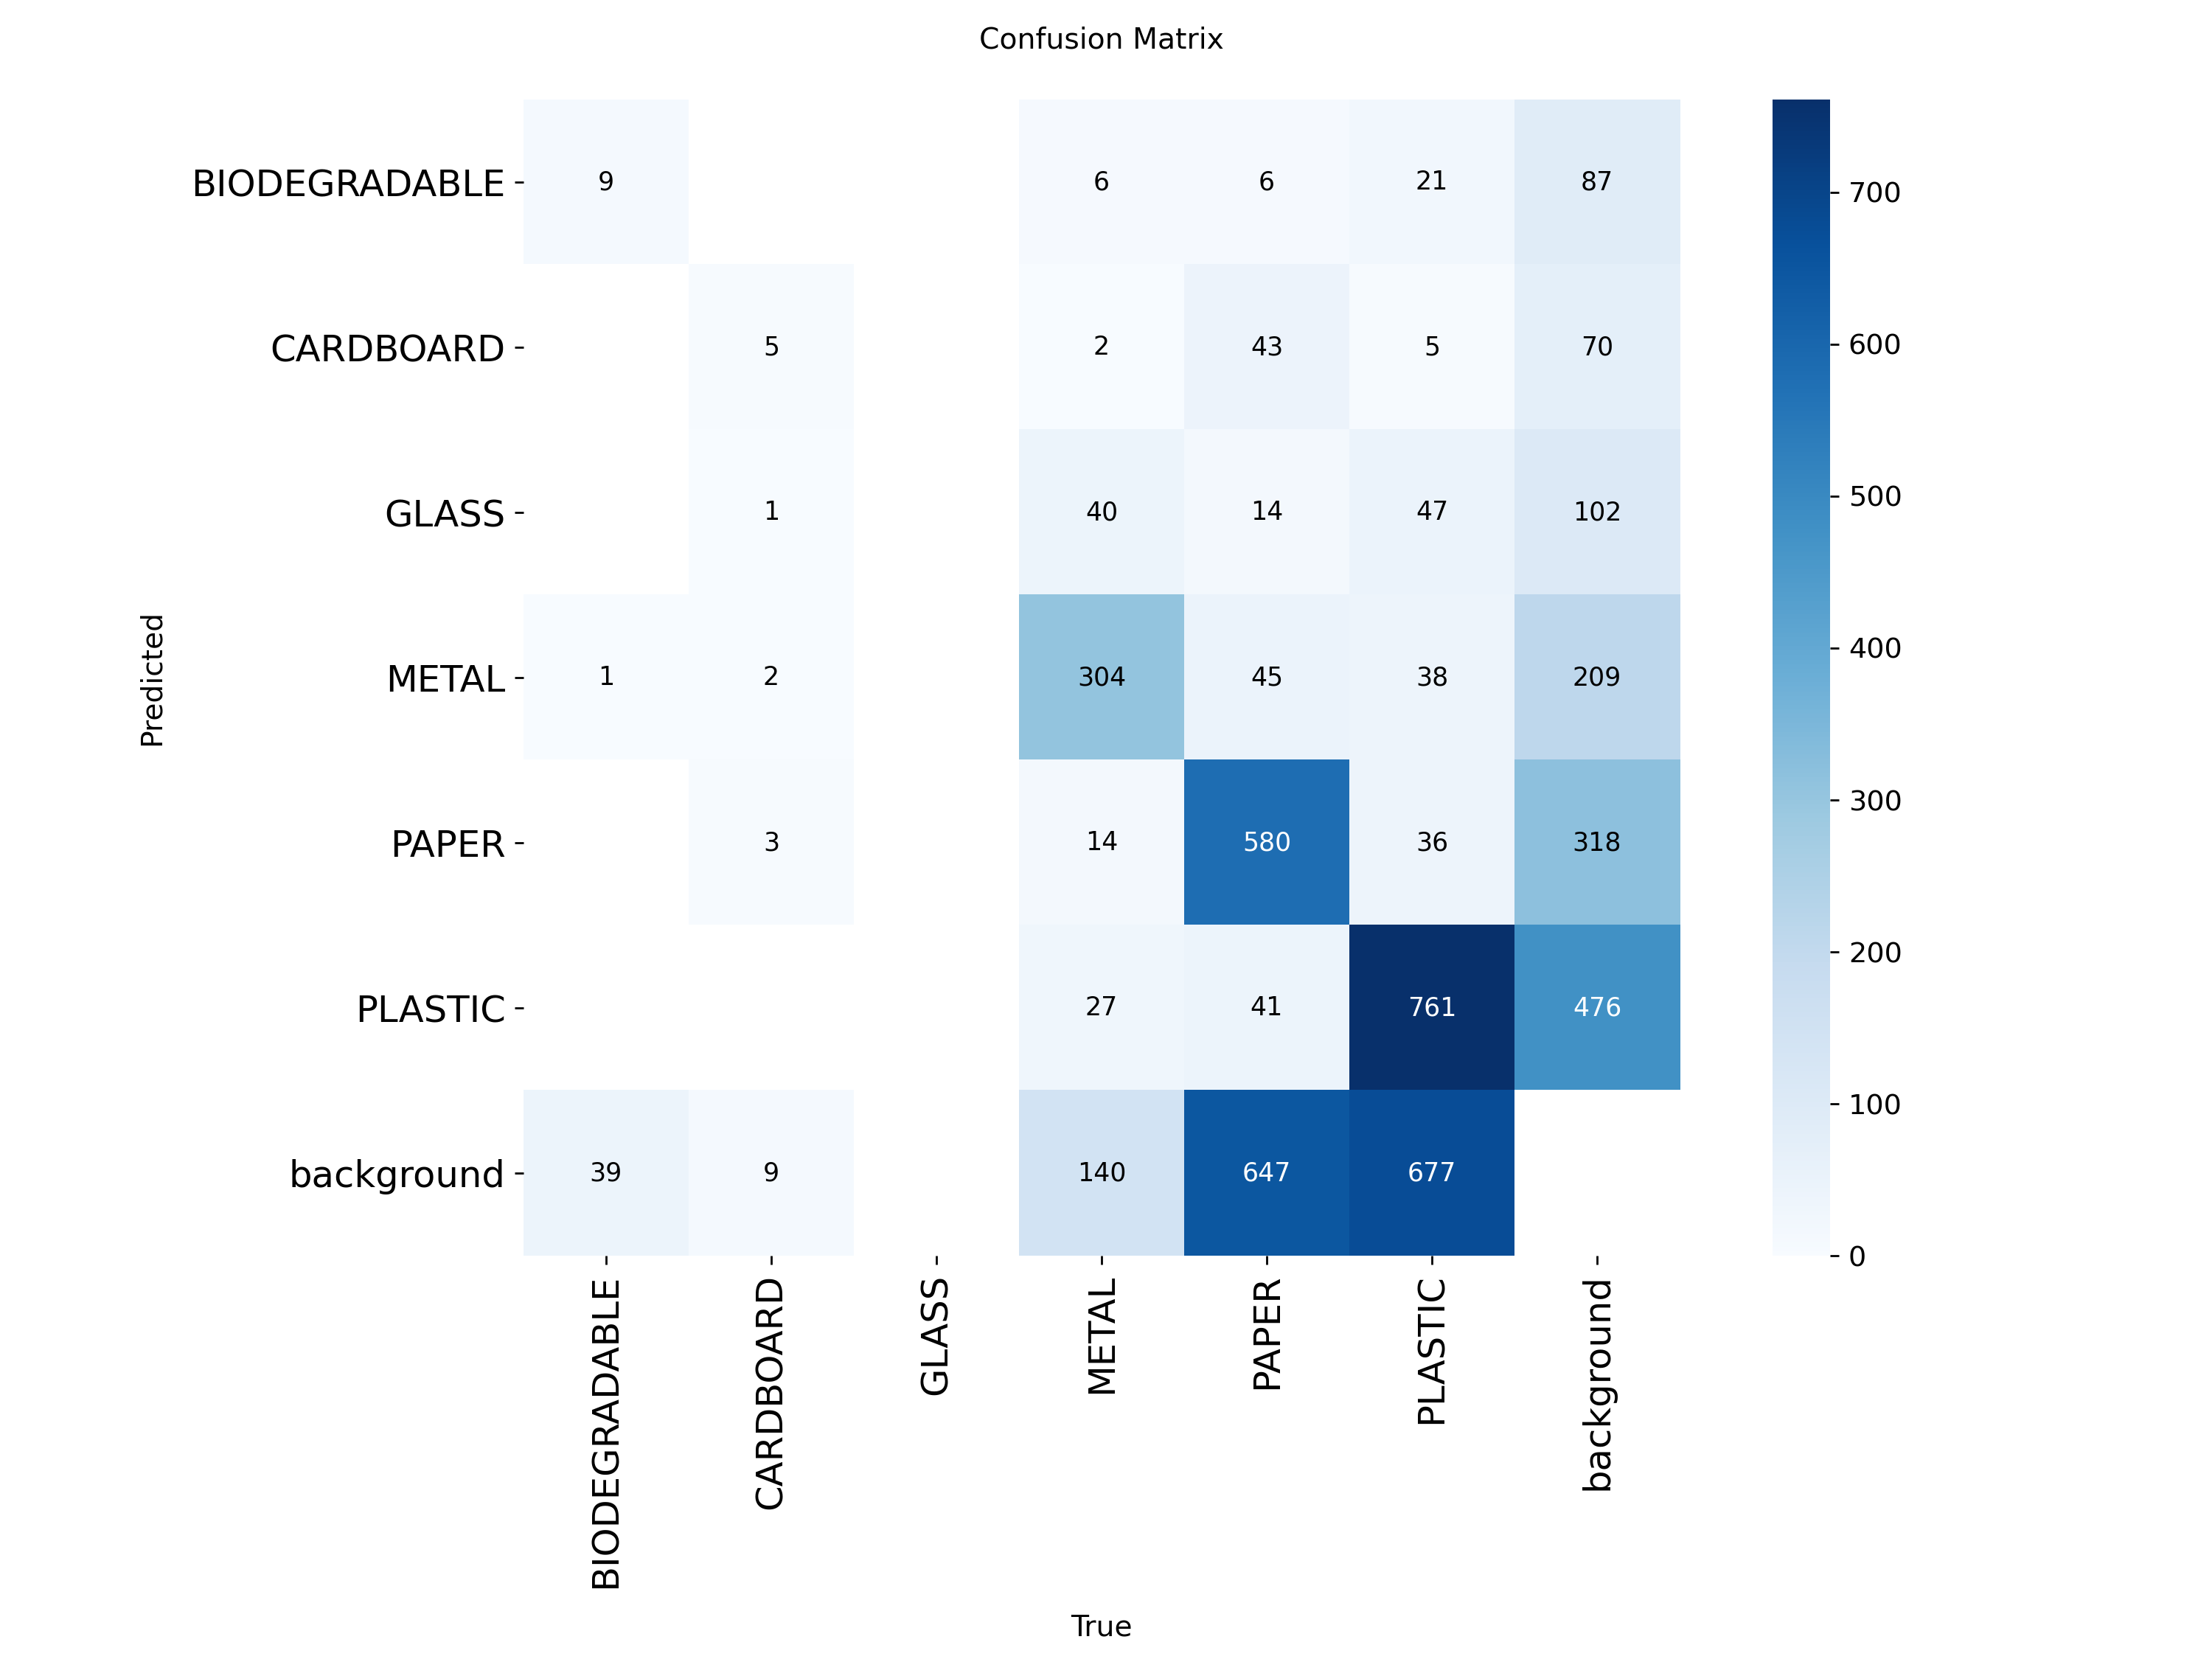

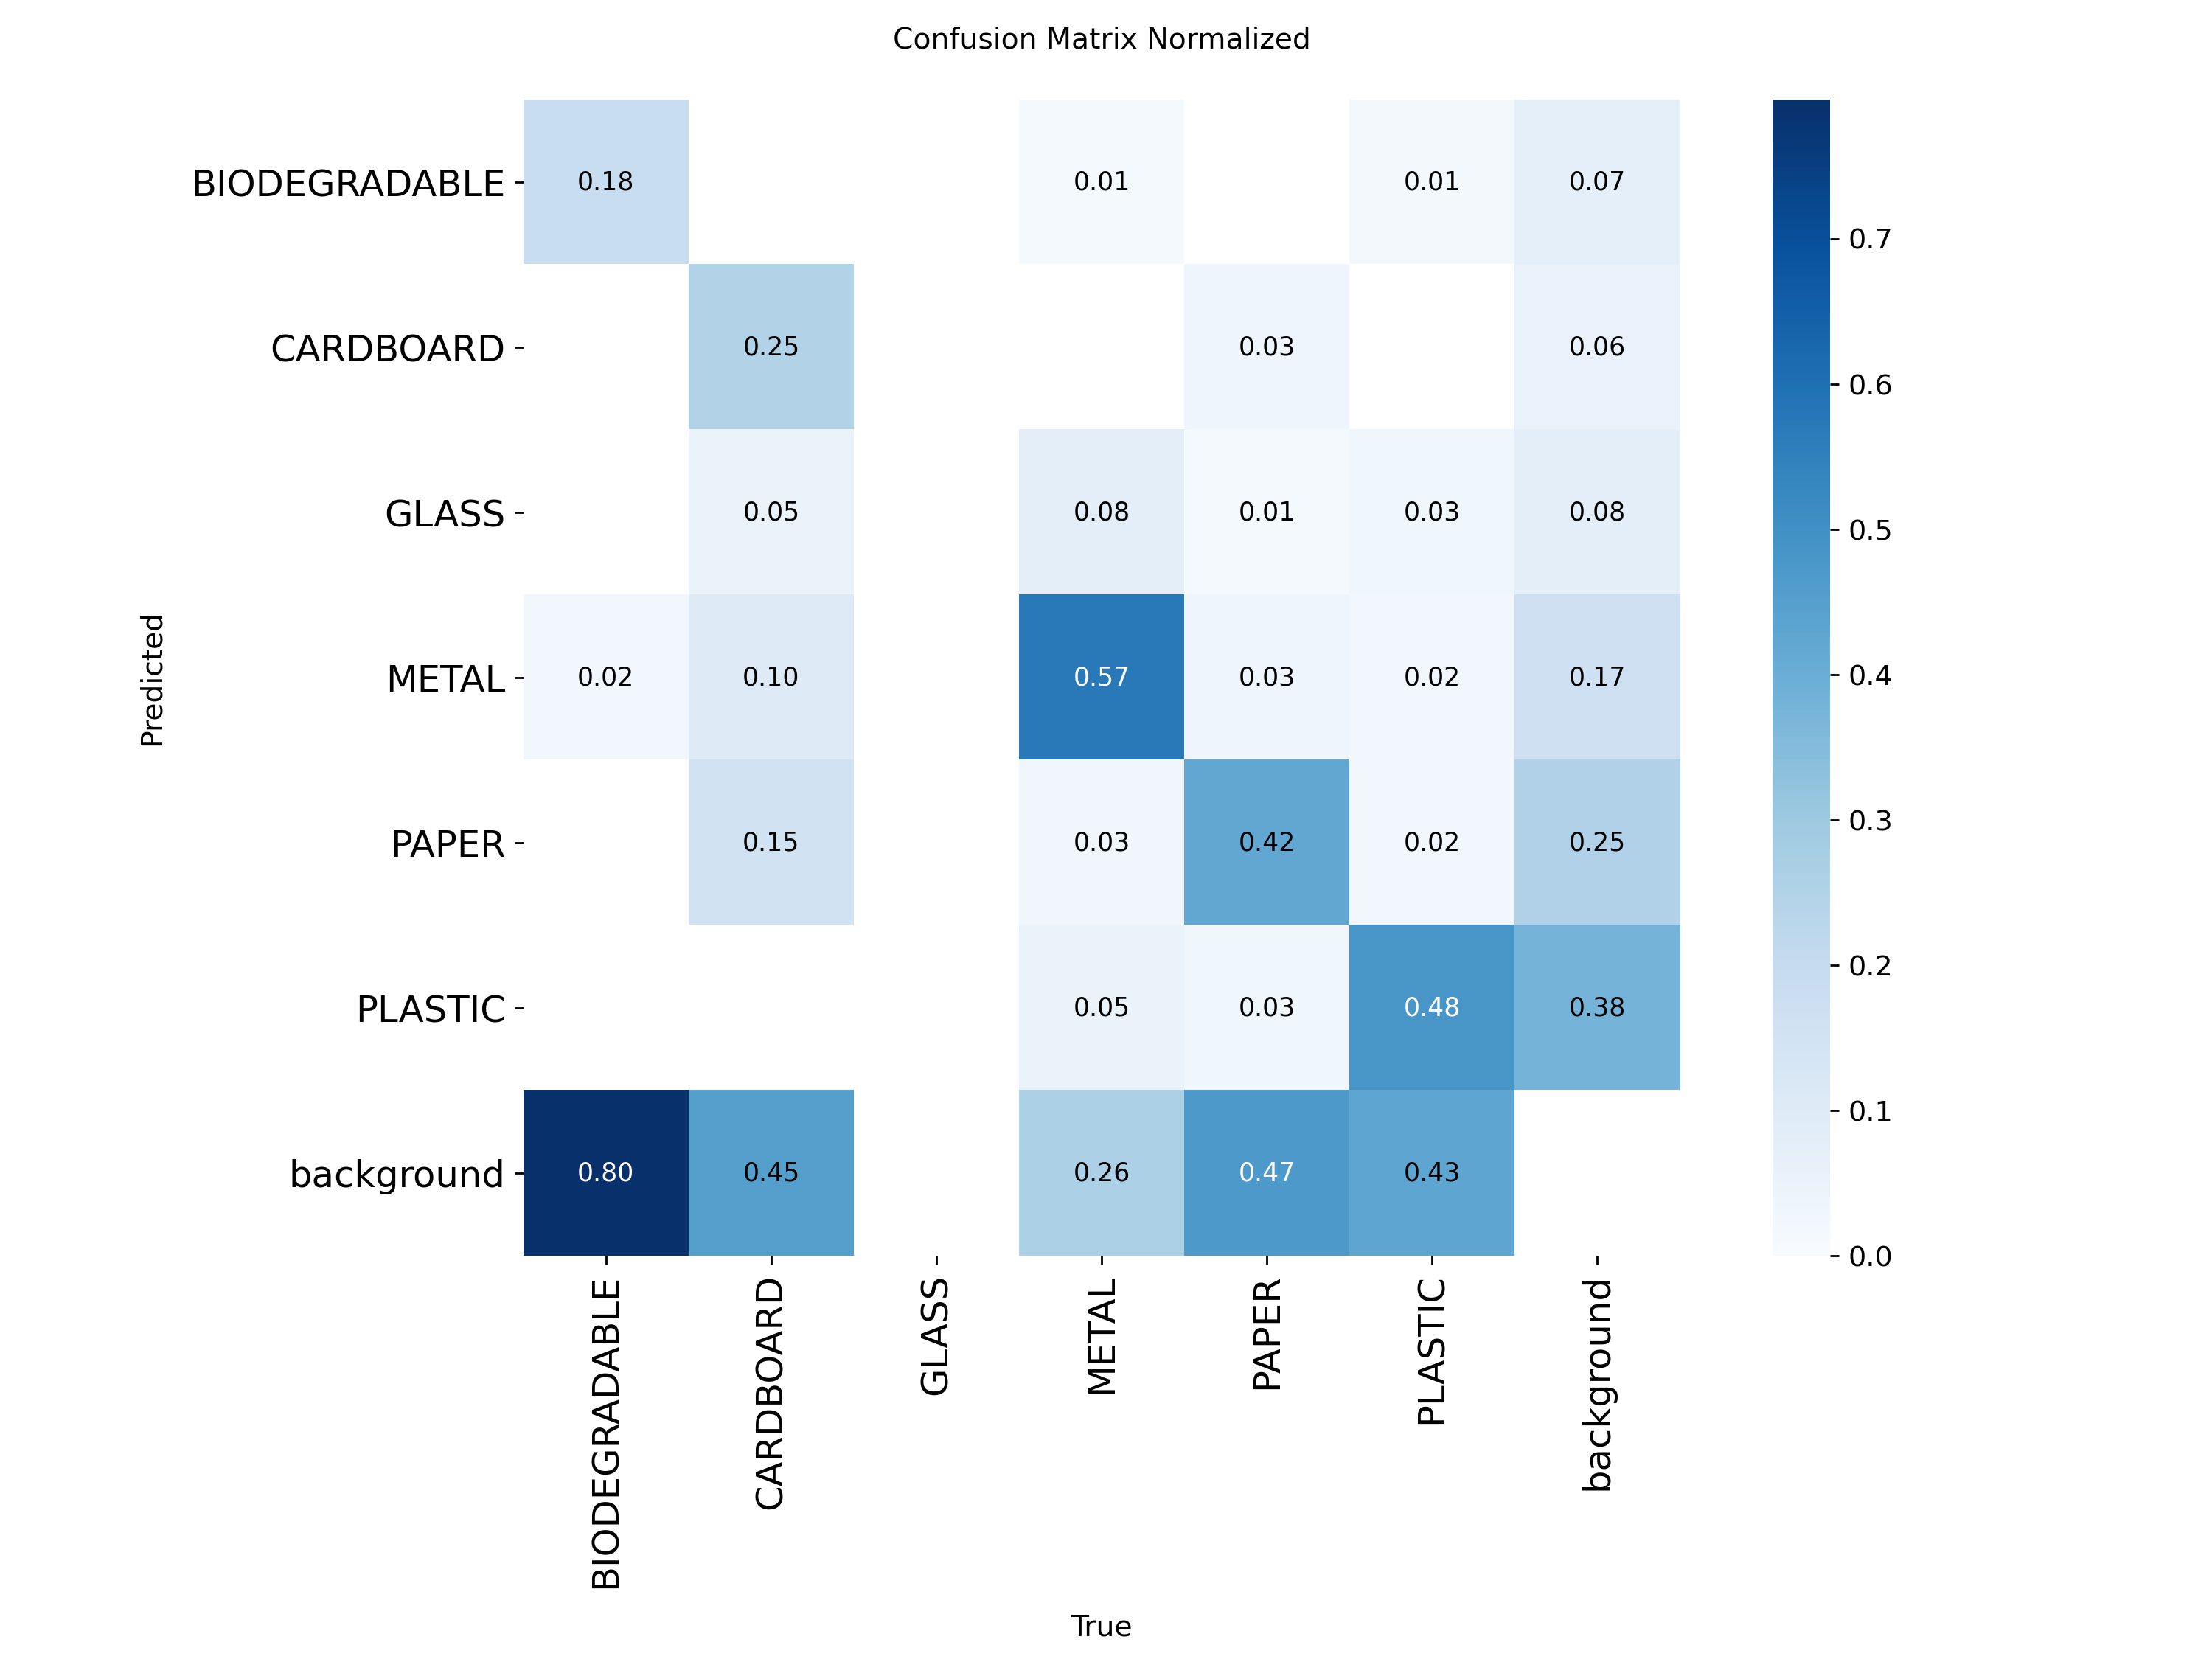

In [20]:
from IPython.display import Image, display

display(Image('/content/runs/detect/test_result/confusion_matrix.png'))
display(Image('/content/runs/detect/test_result/confusion_matrix_normalized.png'))

## Step 5:  YOLOv8 Inference on 5 Test Images


0: 416x416 1 METAL, 3.0ms
1: 416x416 1 GLASS, 3.0ms
2: 416x416 2 METALs, 3.0ms
3: 416x416 1 METAL, 3.0ms
4: 416x416 2 METALs, 3.0ms
Speed: 0.9ms preprocess, 3.0ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict_metal2


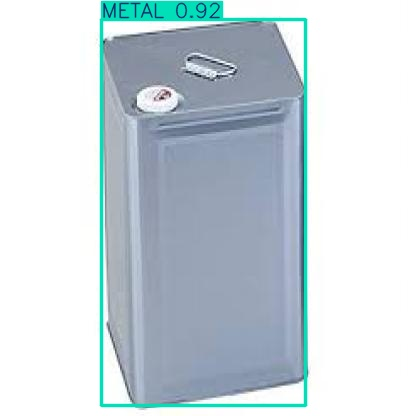

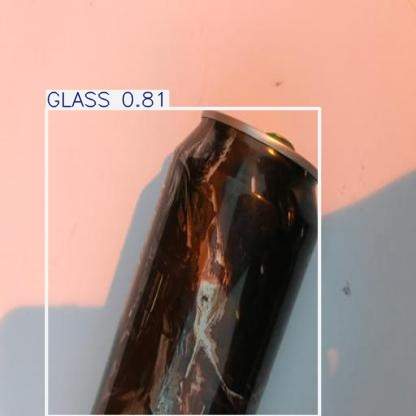

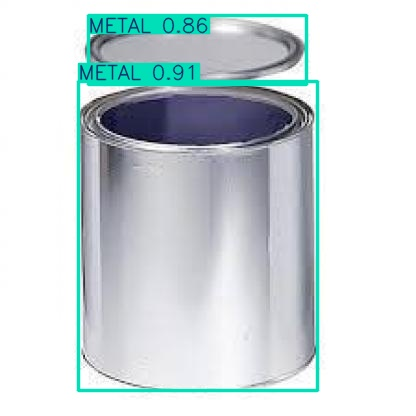

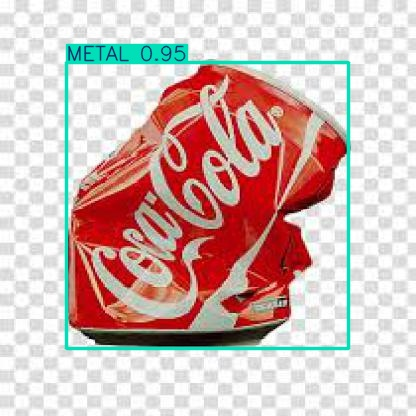

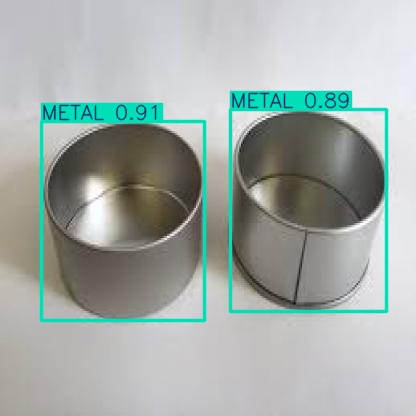

In [22]:
from ultralytics import YOLO
from IPython.display import display, Image

# Load the trained YOLOv8 model
model = YOLO('/content/runs/train/colab_yolo_freeze_head/weights/best.pt')

# List of 5 test image paths to perform inference on
image_paths = [
    '/content/dataset/test/images/metal1000_jpg.rf.f972491130c59d3bff7e97b22e8e2980.jpg',
    '/content/dataset/test/images/metal1005_jpg.rf.d736ab336e8fa92ce57727666e624259.jpg',
    '/content/dataset/test/images/metal100_jpg.rf.8605f3d87c15f6f37575fa2907d5bc6c.jpg',
    '/content/dataset/test/images/metal1014_jpeg.rf.7c66a5a281d17fde9891d5777c496391.jpg',
    '/content/dataset/test/images/metal1016_jpg.rf.e9045ffa8d93980005dca0adcce9f187.jpg'
]

# Run inference and save predictions to the 'predict_metal' folder
results = model.predict(
    source=image_paths,          # Input images
    save=True,                   # Save annotated predictions
    project='runs/detect',       # Root directory for saving results
    name='predict_metal',        # Subfolder name
    conf=0.25                    # Confidence threshold
)

# Display the prediction results inline
for img_path in image_paths:
    filename = img_path.split('/')[-1]
    result_path = f'/content/runs/detect/predict_metal/{filename}'
    display(Image(filename=result_path))


# YOLOv8 Full Fine-tuning

In [23]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='/content/dataset/data.yaml',
    epochs=20,
    imgsz=416,
    batch=8,
    workers=2,
    name='colab_yolo',
    project='/content/runs/train',
    pretrained=True,
    mosaic=0.0,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    flipud=0.0,
    erasing=0.0
)

Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.0, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=colab_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained

train: Scanning /content/dataset/train/labels.cache... 7324 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7324/7324 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.8±25.6 MB/s, size: 15.5 KB)


val: Scanning /content/dataset/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2098/2098 [00:00<?, ?it/s]


...

      20/20      1.72G      1.086      1.083       1.24         65        416: 100%|██████████| 916/916 [01:35<00:00,  9.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:15<00:00,  8.71it/s]


                   all       2098      18916      0.532       0.42      0.465      0.316

20 epochs completed in 0.625 hours.
Optimizer stripped from /content/runs/train/colab_yolo/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/train/colab_yolo/weights/best.pt, 6.2MB

Validating /content/runs/train/colab_yolo/weights/best.pt...
Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:18<00:00,  7.27it/s]


                   all       2098      18916       0.51      0.426      0.465      0.316
         BIODEGRADABLE        676      13637      0.795      0.369      0.552      0.312
             CARDBOARD        438       1292      0.647      0.455      0.541      0.397
                 GLASS        805       2380      0.766      0.641      0.729      0.537
                 METAL        398       1360       0.57      0.547      0.565      0.369
                 PAPER         15         33     0.0154     0.0606     0.0662     0.0656
               PLASTIC         91        214      0.265      0.486       0.34      0.215
Speed: 0.2ms preprocess, 1.5ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to /content/runs/train/colab_yolo


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb946a6f390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

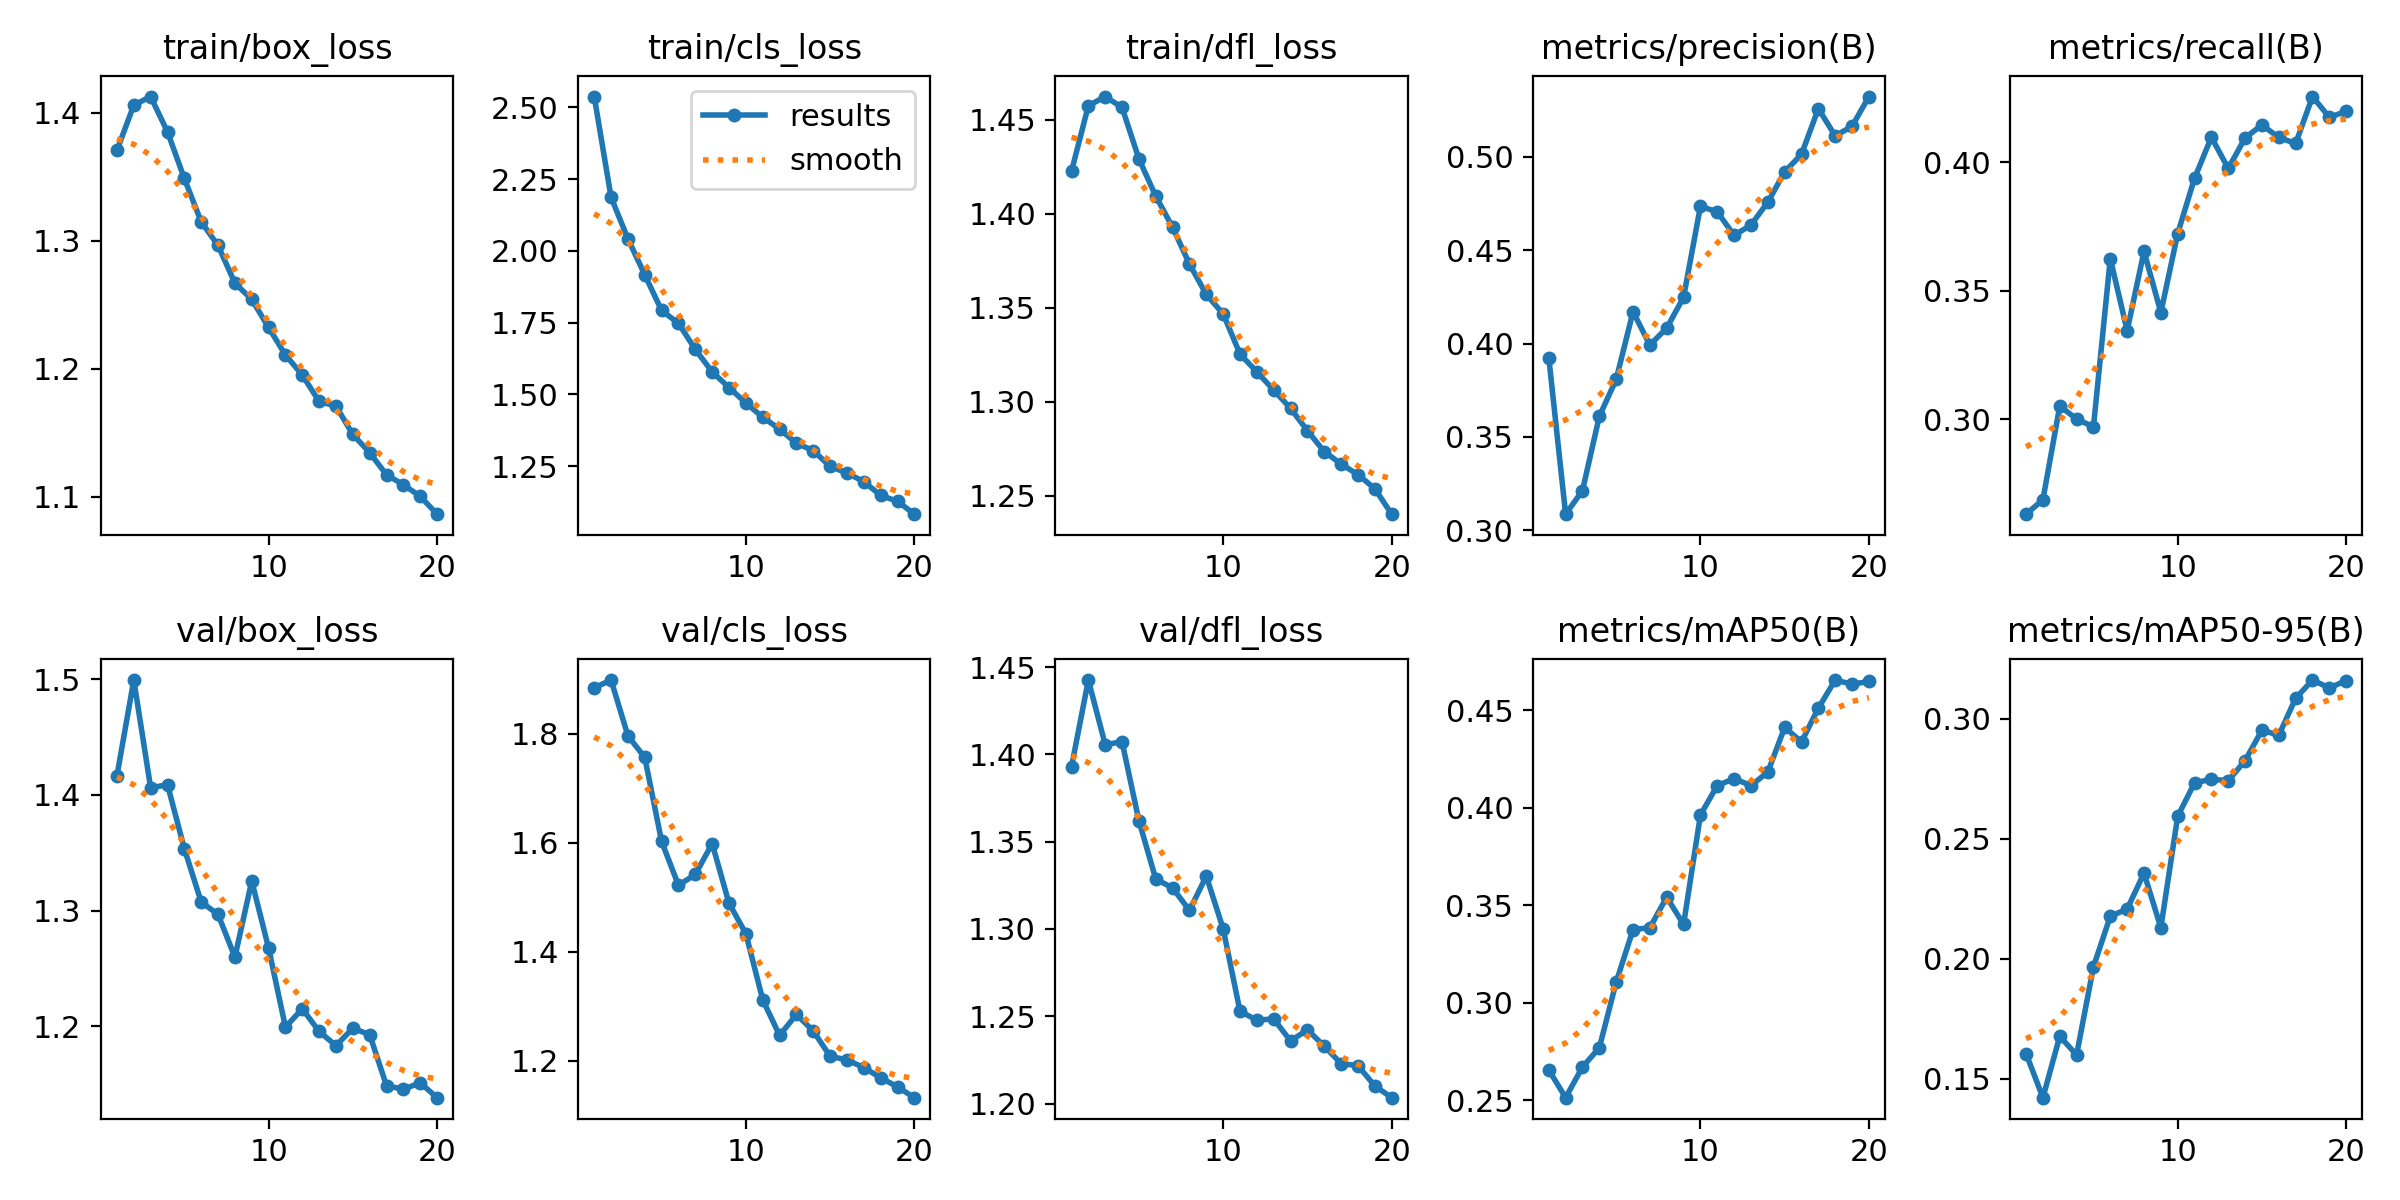

In [24]:
import pandas as pd
from IPython.display import Image

# Load training metrics
df = pd.read_csv('/content/runs/train/colab_yolo/results.csv')
df.tail()

# Plot training curves (loss, mAP)
Image(filename='/content/runs/train/colab_yolo/results.png')

In [25]:
model = YOLO('/content/runs/train/colab_yolo/weights/best.pt')
metrics_val = model.val(data='/content/dataset/data.yaml', split='val', project='runs/detect',name='val_result_full fine tuning')

print("mAP50:", metrics_val.box.map50)         # AP@0.5
print("mAP50-95:", metrics_val.box.map)        # AP@[.5:.95]
print("Precision (mean):", metrics_val.box.mp) # Mean precision
print("Recall (mean):", metrics_val.box.mr)    # Mean recall
print("Per-class AP@50:", metrics_val.box.ap50)   # List of AP@50 per class
print("Per-class AP@50-95:", metrics_val.box.ap)  # List of AP@50-95 per class

Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 564.2±350.8 MB/s, size: 18.4 KB)


val: Scanning /content/dataset/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2098/2098 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 132/132 [00:17<00:00,  7.76it/s]


                   all       2098      18916       0.51      0.425      0.465      0.316
         BIODEGRADABLE        676      13637      0.796      0.368      0.552      0.313
             CARDBOARD        438       1292      0.648      0.454      0.541      0.396
                 GLASS        805       2380      0.766      0.641      0.728      0.537
                 METAL        398       1360      0.571      0.544      0.565      0.369
                 PAPER         15         33     0.0154     0.0606     0.0662     0.0656
               PLASTIC         91        214      0.267      0.486       0.34      0.215
Speed: 0.1ms preprocess, 1.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/val_result_full fine tuning
mAP50: 0.4654015303823851
mAP50-95: 0.31596919824105235
Precision (mean): 0.5104826917593098
Recall (mean): 0.4254411269769917
Per-class AP@50: [    0.55212     0.54077     0.72843     0.56457    0.066218      0.3403]
Per-class AP@50-95: 

In [26]:
model = YOLO('/content/runs/train/colab_yolo/weights/best.pt')
metrics = model.val(
    data='/content/dataset/data.yaml',
    split='test',
    project='runs/detect',
    name='test_result_full fine tuning'
)

print("mAP50:", metrics.box.map50)         # AP@0.5
print("mAP50-95:", metrics.box.map)        # AP@[.5:.95]
print("Precision (mean):", metrics.box.mp) # Mean precision
print("Recall (mean):", metrics.box.mr)    # Mean recall
print("Per-class AP@50:", metrics.box.ap50)   # List of AP@50 per class
print("Per-class AP@50-95:", metrics.box.ap)  # List of AP@50-95 per class


Ultralytics 8.3.165 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 682.0±393.0 MB/s, size: 26.8 KB)


val: Scanning /content/dataset/test/labels.cache... 1042 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1042/1042 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 66/66 [00:09<00:00,  7.30it/s]


                   all       1042       3563      0.429      0.383      0.371      0.273
         BIODEGRADABLE          8         49      0.149      0.163     0.0928     0.0499
             CARDBOARD         11         20     0.0245       0.15     0.0223     0.0141
                 METAL        172        533      0.642      0.634      0.632      0.493
                 PAPER        515       1376      0.642      0.469      0.524      0.412
               PLASTIC        354       1585      0.689      0.498      0.585      0.396
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/test_result_full fine tuning
mAP50: 0.3712744068958448
mAP50-95: 0.27310850034818535
Precision (mean): 0.429409287347924
Recall (mean): 0.38291380535572667
Per-class AP@50: [   0.092835    0.022299     0.63234     0.52438     0.58451]
Per-class AP@50-95: [   0.049877    0.014064     0.49349     0.41205     0.39606]



0: 416x416 1 CARDBOARD, 1 GLASS, 1 METAL, 6.4ms
1: 416x416 1 GLASS, 6.4ms
2: 416x416 2 METALs, 6.4ms
3: 416x416 1 CARDBOARD, 1 METAL, 6.4ms
4: 416x416 4 METALs, 6.4ms
Speed: 1.4ms preprocess, 6.4ms inference, 4.6ms postprocess per image at shape (1, 3, 416, 416)
Results saved to runs/detect/predict_metal3


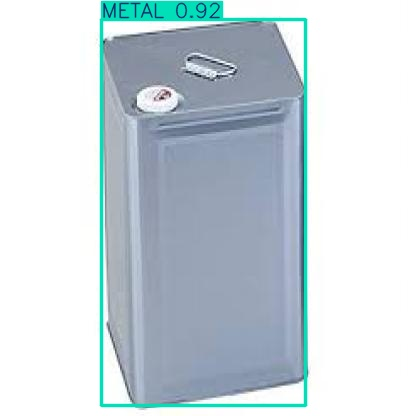

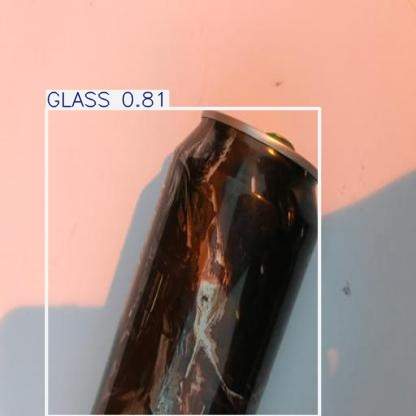

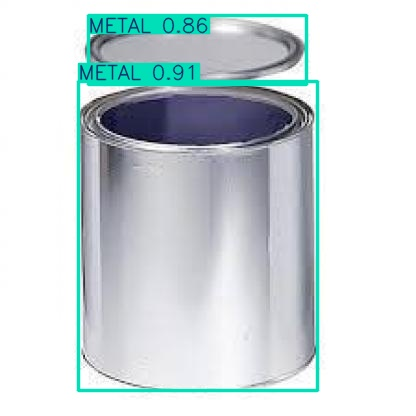

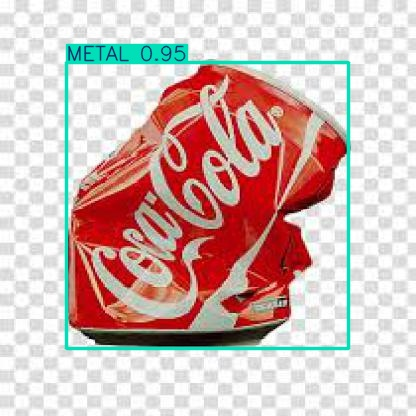

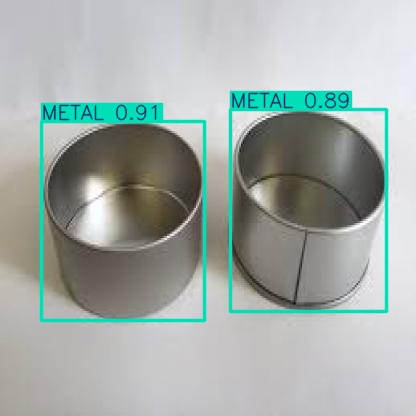

In [27]:
from ultralytics import YOLO
from IPython.display import display, Image

# Load the trained YOLOv8 model
model = YOLO('/content/runs/train/colab_yolo/weights/best.pt')

# List of 5 test image paths to perform inference on
image_paths = [
    '/content/dataset/test/images/metal1000_jpg.rf.f972491130c59d3bff7e97b22e8e2980.jpg',
    '/content/dataset/test/images/metal1005_jpg.rf.d736ab336e8fa92ce57727666e624259.jpg',
    '/content/dataset/test/images/metal100_jpg.rf.8605f3d87c15f6f37575fa2907d5bc6c.jpg',
    '/content/dataset/test/images/metal1014_jpeg.rf.7c66a5a281d17fde9891d5777c496391.jpg',
    '/content/dataset/test/images/metal1016_jpg.rf.e9045ffa8d93980005dca0adcce9f187.jpg'
]

# Run inference and save predictions to the 'predict_metal' folder
results = model.predict(
    source=image_paths,          # Input images
    save=True,                   # Save annotated predictions
    project='runs/detect',       # Root directory for saving results
    name='predict_metal',        # Subfolder name
    conf=0.25                    # Confidence threshold
)

# Display the prediction results inline
for img_path in image_paths:
    filename = img_path.split('/')[-1]
    result_path = f'/content/runs/detect/predict_metal/{filename}'
    display(Image(filename=result_path))
